# Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import os
import nltk
import matplotlib.pyplot as plt
import seaborn

from pathlib import Path
from nltk.probability import FreqDist
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
from nltk import bigrams as make_bigrams
from collections import Counter
from tqdm.auto import tqdm

In [2]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /Users/jacob/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /Users/jacob/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /Users/jacob/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jacob/nltk_data...
[nltk_data] Downloading package wordnet to /Users/jacob/nltk_data...
[nltk_data] Downloading package omw-1.4 to /Users/jacob/nltk_data...


True

# Datasets

## Creation

In [3]:
def create_speeches_df(root_dir):
    root_dir = Path(root_dir)
    data = []

    # Iter for the folders inside TXT
    for subfolder in sorted(root_dir.iterdir()):
        if not subfolder.is_dir():
            continue

        # Extract session number and year from the folder name, e.g. "Session 25 - 1970"
        match = re.match(r"Session (\d+) - (\d+)", subfolder.name)
        if not match:
            continue  # skip anything that doesn't match the expected pattern
        session_number, year = int(match.group(1)), int(match.group(2))

        for file in subfolder.iterdir():
            if not file.is_file() or file.name.startswith("."):
                continue

            country_code = file.name.split("_")[0]
            with open(file, encoding="utf-8") as f:
                speech_text = f.read()

            data.append([session_number, year, country_code, speech_text])

    return pd.DataFrame(data, columns=['session_number', 'year', 'country_code', 'speech_text'])

In [4]:
def create_df_from_csv(file_path,sep=','):
    df = pd.read_csv(file_path, sep=sep)
    return df

In [5]:
df_speeches_raw = create_speeches_df('data/TXT')
display(df_speeches_raw.info())
display(df_speeches_raw.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11141 entries, 0 to 11140
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   session_number  11141 non-null  int64 
 1   year            11141 non-null  int64 
 2   country_code    11141 non-null  object
 3   speech_text     11141 non-null  object
dtypes: int64(2), object(2)
memory usage: 348.3+ KB


None

,session_number,year,country_code,speech_text
7566,62,2007,KNA,I have the honour to address the General Asse...
6096,54,1999,COL,"Allow me, on\nmy own behalf and on behalf of m..."
9725,73,2018,NAM,I wish to congratulate Ms. María Fernanda ...
4343,44,1989,COM,"﻿\nSir, I should like first to convey to you, ..."
3308,37,1982,PAN,"Mr. President, your many years of association ..."
4978,48,1993,KOR,May I congratulate\nAmbassador Insanally of Gu...
6081,54,1999,ARE,"Mr. President, it gives me pleasure to extend ..."
5650,52,1997,GMB,﻿Allow me first of all to extend\nmy delegatio...
7922,64,2009,IRL,"Let me begin, \nMr. President, by warmly congr..."
42,2,1947,IND,We meet today in a disturbed and unhappy world...


## Cleaning and Preproccessing

In [6]:
tqdm.pandas()

In [7]:
# Reset index
df_speeches = df_speeches_raw.set_index(['year','country_code'])

# Lowercase the speec
df_speeches['speech_text'] = df_speeches['speech_text'].str.lower()

# Remove special characters
df_speeches['speech_text'] = (
    df_speeches['speech_text']
    .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [8]:
# Remove stop words
stop = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    new_text = [t for t in tokens if t not in stop]
    return new_text

# Tokenize
df_speeches['tokens'] = df_speeches['speech_text'].progress_apply(remove_stopwords)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [9]:
# Lemmatize
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    lemmatized = []
    for t in tokens:
        lemmatized.append(lemmatizer.lemmatize(t))
    return lemmatized

df_speeches['lemmatization'] = df_speeches['tokens'].progress_apply(lemmatize_tokens)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [10]:
# Determine the length of the speeches
df_speeches['speech_length'] = (
    df_speeches['speech_text']
    .str.split()
    .str.len()
)
df_speeches['tokens_length'] = df_speeches['tokens'].str.len()

In [11]:
df_speeches.sample(5)

,,session_number,speech_text,tokens,lemmatization,speech_length,tokens_length
year,country_code,,,,,,
1975,JAM,30,let me begin by expressing on behalf of the go...,"[let, begin, expressing, behalf, government, p...","[let, begin, expressing, behalf, government, p...",2847,1416
1993,GNB,48,allow me at the outset sir to offer you my war...,"[allow, outset, sir, offer, warmest, congratul...","[allow, outset, sir, offer, warmest, congratul...",3667,1941
2023,GMB,78,i bring the general assembly warm greetings an...,"[bring, general, assembly, warm, greetings, go...","[bring, general, assembly, warm, greeting, goo...",2130,1182
1958,POL,13,a year ago from this very rostrum i had the ho...,"[year, ago, rostrum, honour, outline, benefit,...","[year, ago, rostrum, honour, outline, benefit,...",3031,1495
2025,ETH,80,the assembly will now hear an address by his e...,"[assembly, hear, address, excellency, taye, ak...","[assembly, hear, address, excellency, taye, ak...",1480,849


# Exploratory

## Speeches

### Length

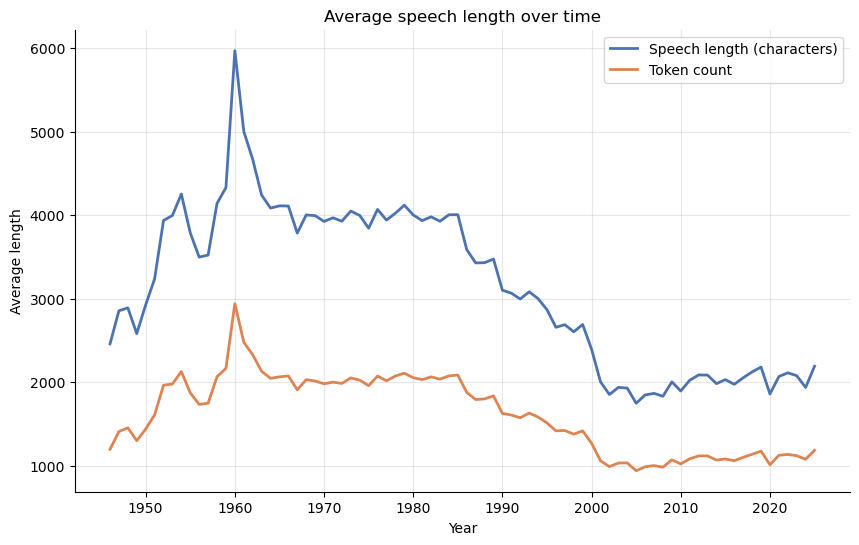

In [12]:
# Lengths of speeches accross time
avg_lengths = df_speeches.groupby(level='year')[['speech_length', 'tokens_length']].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(avg_lengths.index, avg_lengths['speech_length'],
        color='#4C72B0', linewidth=2, label='Speech length (characters)')
ax.plot(avg_lengths.index, avg_lengths['tokens_length'],
        color='#DD8452', linewidth=2, label='Token count')

ax.set_xlabel('Year')
ax.set_ylabel('Average length')
ax.set_title('Average speech length over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### ngrams

In [13]:
df_ngrams = df_speeches.copy()

In [14]:
# Unigrams
unigrams = {
    'warming','carbon','dioxide','emissions','greenhouse','fossil','methane','ozone','atmosphere',
    'drought','wildfires','flooding','deforestation',
    'climate','weather','renewable'
    }

In [15]:
# Corpus pairs
ngrams_2 = Counter(p for toks in df_speeches['lemmatization'] for p in make_bigrams(toks))

In [16]:
ngrams_2.most_common(1000)

[(('united', 'nation'), 153392),
 (('general', 'assembly'), 40975),
 (('international', 'community'), 32681),
 (('security', 'council'), 29182),
 (('human', 'right'), 26551),
 (('secretary', 'general'), 24832),
 (('united', 'state'), 23387),
 (('developing', 'country'), 22784),
 (('peace', 'security'), 20834),
 (('co', 'operation'), 20264),
 (('middle', 'east'), 15548),
 (('member', 'state'), 14229),
 (('south', 'africa'), 14030),
 (('session', 'general'), 13007),
 (('nuclear', 'weapon'), 12338),
 (('economic', 'social'), 11609),
 (('climate', 'change'), 10876),
 (('sustainable', 'development'), 10644),
 (('international', 'peace'), 10599),
 (('per', 'cent'), 10030),
 (('developed', 'country'), 9940),
 (('would', 'like'), 9416),
 (('soviet', 'union'), 8801),
 (('self', 'determination'), 8539),
 (('international', 'law'), 8271),
 (('international', 'economic'), 7070),
 (('viet', 'nam'), 6984),
 (('people', 'republic'), 6940),
 (('international', 'relation'), 6673),
 (('last', 'year'), 6

In [17]:
# Test for different words the most common bigrams
[(p, c) for p, c in ngrams_2.most_common(10000) if "climate" in p][:30]

[(('climate', 'change'), 10876),
 (('convention', 'climate'), 979),
 (('impact', 'climate'), 687),
 (('effect', 'climate'), 658),
 (('agreement', 'climate'), 601),
 (('climate', 'action'), 519),
 (('international', 'climate'), 473),
 (('climate', 'crisis'), 429),
 (('political', 'climate'), 373),
 (('global', 'climate'), 250),
 (('climate', 'peace'), 239),
 (('challenge', 'climate'), 229),
 (('fight', 'climate'), 226),
 (('issue', 'climate'), 210),
 (('address', 'climate'), 197),
 (('create', 'climate'), 185),
 (('climate', 'finance'), 182),
 (('climate', 'fund'), 173),
 (('consequence', 'climate'), 162),
 (('panel', 'climate'), 159),
 (('threat', 'climate'), 156),
 (('new', 'climate'), 155),
 (('green', 'climate'), 155),
 (('climate', 'financing'), 146),
 (('climate', 'confidence'), 145),
 (('climate', 'conducive'), 143),
 (('development', 'climate'), 142),
 (('combat', 'climate'), 140)]

In [18]:
# Bigrams
bigrams = {
    # Energy
    ('renewable', 'energy'),('energy', 'resource'),('energy', 'crisis'),
    ('energy', 'source'),('clean', 'energy'),('sustainable', 'energy'),
    # Climate
    ('climate', 'change'),('climate', 'crisis'),
    # Carbon
    ('carbon','dioxide'),('carbon','emission'),
    # Other
    ('global','warming'),('carbon','dioxide'),('extreme','weather'),
    ('greenhouse','gas'),('greenhouse','gases'),('natural','disasters'),
    ('fossil','fuels'),('gas', 'emission'),
    # Natural
    ('natural', 'resource'),('natural', 'disaster')
   }

In [19]:
# Count appereances in speeches
def count_terms(tokens):
    uni = sum(1 for u in tokens if u in unigrams)
    bi = sum(1 for b in make_bigrams(tokens) if b in bigrams)
    return pd.Series({'unigram_count':uni, 'bigram_count':bi})

df_ngrams[['unigram_count','bigram_count']]= df_ngrams['lemmatization'].progress_apply(count_terms)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [20]:
# See the speech with the higher count
df_ngrams.sort_values('unigram_count',ascending=False)['speech_text'].iloc[0]

'last friday ushered in a new era in our search for an innovative plan of action for people and the planet the significant milestone event was the adoption by the united nations of the new set of sustainable development goals as part of the agenda for sustainable development resolution our sustainable development goals are inspirational and ambitious they are global in nature and universally applicable to every united nations member state developed and developing alike every goal is important and deserves priority attention they are interrelated they carry equal weight and they all matter achieving some goals at the expense of others is not a preferred option all goals must be realized which should be the overriding objective in my firm belief in the importance of the work of our organization i have tried to attend the annual general assembly debates as often as possible since becoming samoa s prime minister i am therefore acutely aware of the diversity and gravity of issues confrontin

In [21]:
# Determine if a speech has or not unigrams or bigrams
df_ngrams['has_unigram'] = df_ngrams['unigram_count'].apply(lambda x: 1 if x > 0 else 0)
df_ngrams['has_bigram'] = df_ngrams['bigram_count'].apply(lambda x: 1 if x > 0 else 0)

In [22]:
# Rate of mentions per speech
df_ngrams['unigram_rate'] = df_ngrams['unigram_count']/df_ngrams['tokens_length']*1000
df_ngrams['bigram_rate'] = df_ngrams['bigram_count']/df_ngrams['tokens_length']*1000

In [23]:
# Agroupation by year

# Option A mean of ratios
yearly_A = df_ngrams.groupby('year')[['unigram_rate','bigram_rate']].mean()

# Option general proportion
yearly_B = df_ngrams.groupby('year')[['unigram_count','bigram_count','tokens_length']].sum()
yearly_B['yearly_unigram_rate'] = yearly_B['unigram_count']/yearly_B['tokens_length']*1000
yearly_B['yearly_bigram_rate'] = yearly_B['bigram_count']/yearly_B['tokens_length']*1000

# Option to count countries that incorporated terms in their speeches
yearly_C = df_ngrams.groupby('year')[['has_unigram','has_bigram']].sum()


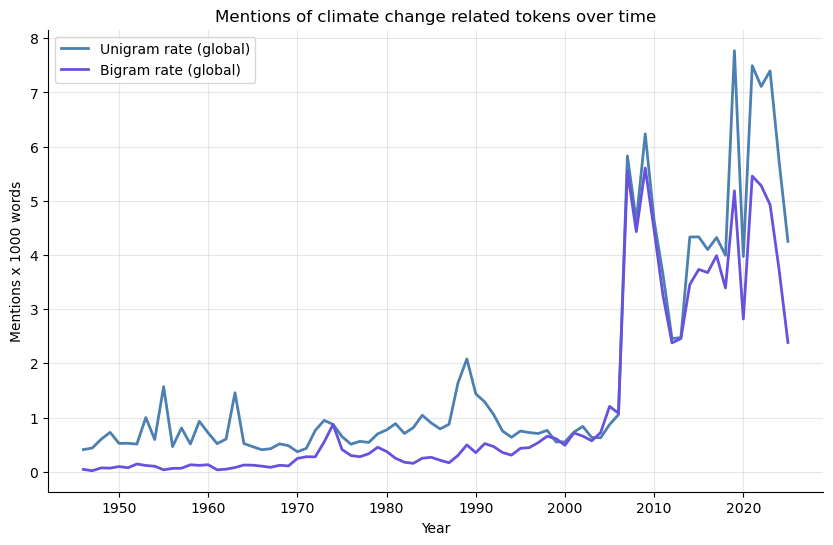

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

# ax.plot(yearly_A.index, yearly_A['unigram_rate'],
#         color="#B08F4C", linewidth=2, label='Unigram rate (mean of means)')
# ax.plot(yearly_A.index, yearly_A['bigram_rate'],
#         color="#DD9152", linewidth=2, label='Bigram rate (mean of means)')

ax.plot(yearly_B.index, yearly_B['yearly_unigram_rate'],
        color="#4C80B0", linewidth=2, label='Unigram rate (global)')
ax.plot(yearly_B.index, yearly_B['yearly_bigram_rate'],
        color="#6752DD", linewidth=2, label='Bigram rate (global)')

ax.set_xlabel('Year')
ax.set_ylabel('Mentions x 1000 words')
ax.set_title('Mentions of climate change related tokens over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

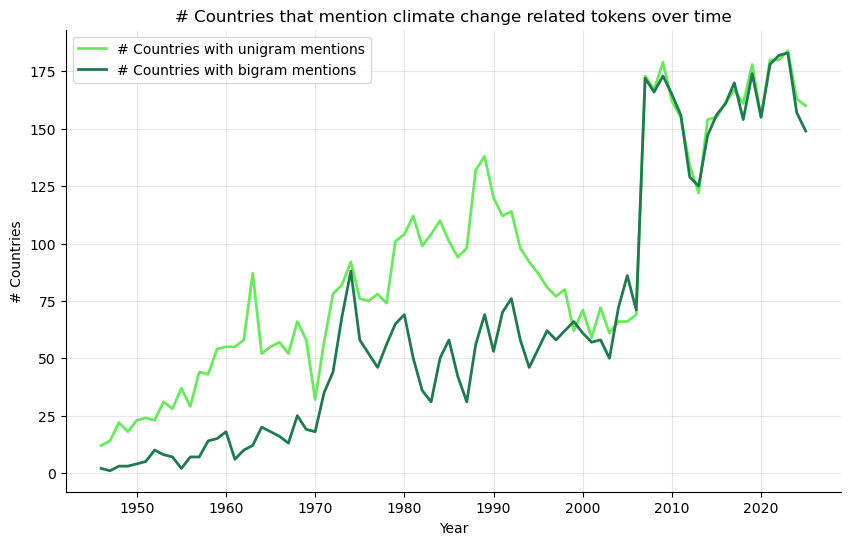

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_C.index, yearly_C['has_unigram'],
        color="#68EA5C", linewidth=2, label='# Countries with unigram mentions')
ax.plot(yearly_C.index, yearly_C['has_bigram'],
        color="#1E7A4F", linewidth=2, label='# Countries with bigram mentions')

ax.set_xlabel('Year')
ax.set_ylabel('# Countries')
ax.set_title('# Countries that mention climate change related tokens over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### Climate change vs energy frequency

In [26]:
df_cc_vs_re = df_speeches.copy()

In [27]:
# Bigrams

# Energy
re_bigrams = {
    # Energy
    ('renewable', 'energy'),('energy', 'resource'),('energy', 'crisis'),
    ('energy', 'source'),('clean', 'energy'),('sustainable', 'energy')
   }

# Climate change
cc_bigrams = {
    # Climate
        ('climate', 'change'),('climate', 'crisis'),
        # Carbon
        ('carbon','dioxide'),('carbon','emission'),
        # Other
        ('global','warming'),('carbon','dioxide'),('extreme','weather'),
        ('greenhouse','gas'),('greenhouse','gases'),('natural','disasters'),
        ('fossil','fuels'),('gas', 'emission'),
        # Natural
        ('natural', 'resource'),('natural', 'disaster')
    }

In [28]:
# Count appereances in speeches
def count_vs_terms(tokens):
    energy = sum(1 for u in tokens if u in re_bigrams)
    climate = sum(1 for b in make_bigrams(tokens) if b in cc_bigrams)
    return pd.Series({'renewable_energy_count':energy, 'climate_change_count':climate})

df_cc_vs_re[['unigram_count','bigram_count']]= df_cc_vs_re['lemmatization'].progress_apply(count_vs_terms)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [29]:
df_ngrams.sample(5)

,,session_number,speech_text,tokens,lemmatization,speech_length,tokens_length,unigram_count,bigram_count,has_unigram,has_bigram,unigram_rate,bigram_rate
year,country_code,,,,,,,,,,,,
2023,WSM,78,samoa extends its congratulations and best wis...,"[samoa, extends, congratulations, best, wishes...","[samoa, extends, congratulation, best, wish, m...",1868,1043,16,10,1,1,15.340364,9.587728
1966,ECU,21,the opening of each yearly session of the gene...,"[opening, yearly, session, general, assembly, ...","[opening, yearly, session, general, assembly, ...",4818,2421,0,0,0,0,0.000000,0.000000
1971,FRA,26,it is toward asia where all the problems of th...,"[toward, asia, problems, world, ferment, whose...","[toward, asia, problem, world, ferment, whose,...",4895,2389,2,0,1,0,0.837170,0.000000
2003,NPL,58,i greet julian hunte warmly as president at th...,"[greet, julian, hunte, warmly, president, sess...","[greet, julian, hunte, warmly, president, sess...",2196,1229,1,0,1,0,0.813670,0.000000
1984,MAR,39,before beginning my statement sir i wish to co...,"[beginning, statement, sir, wish, convey, beha...","[beginning, statement, sir, wish, convey, beha...",3496,1821,2,1,1,1,1.098298,0.549149


# Geopandas visualisations

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the shapefile you unzipped into the data folder
world = gpd.read_file('./data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

country_agg = df_ngrams.groupby('country_code').agg(
    total_bigram_count=('bigram_count', 'sum'),
    total_tokens=('tokens_length', 'sum')
).reset_index()

country_agg['bigram_rate_1000'] = (
    country_agg['total_bigram_count']
)


session_number  \
year country_code                   
1946 LBR                        1   
     UKR                        1   
     IRN                        1   
     CAN                        1   
     HTI                        1   
...                           ...   
2025 KGZ                       80   
     LBN                       80   
     AUS                       80   
     NLD                       80   
     TGO                       80   

                                                         speech_text  \
year country_code                                                      
1946 LBR           i give you the greetings of the government and...   
     UKR           the day before yesterday the head of the deleg...   
     IRN           during the first part of the first session of ...   
     CAN           if were not anxious like all my colleagues to ...   
     HTI           a new world is being born from the fragments o...   
...                                                              ...   
2025 KGZ           the assembly will now hear an address by his e...   
     LBN           the assembly will hear and address by his exce...   
     AUS           now the assembly will hear an address by his e...   
     NLD           the assembly will now hear an address by his e...   
     TGO           i now give the floor to his excellency mr robe...   

                                                              tokens  \
year country_code                                                      
1946 LBR           [give, greetings, government, people, liberia,...   
     UKR           [day, yesterday, head, delegation, union, sovi...   
     IRN           [first, part, first, session, general, assembl...   
     CAN           [anxious, like, colleagues, take, consideratio...   
     HTI           [new, world, born, fragments, world, torn, asu...   
...                                                              ...   
2025 KGZ           [assembly, hear, address, excellency, sadra, s...   
     LBN           [assembly, hear, address, excellency, joseph, ...   
     AUS           [assembly, hear, address, excellency, antony, ...   
     NLD           [assembly, hear, address, excellency, dick, sk...   
     TGO           [give, floor, excellency, mr, robert, kholan, ...   

                                                       lemmatization  \
year country_code                                                      
1946 LBR           [give, greeting, government, people, liberia, ...   
     UKR           [day, yesterday, head, delegation, union, sovi...   
     IRN           [first, part, first, session, general, assembl...   
     CAN           [anxious, like, colleague, take, consideration...   
     HTI           [new, world, born, fragment, world, torn, asun...   
...                                                              ...   
2025 KGZ           [assembly, hear, address, excellency, sadra, s...   
     LBN           [assembly, hear, address, excellency, joseph, ...   
     AUS           [assembly, hear, address, excellency, antony, ...   
     NLD           [assembly, hear, address, excellency, dick, sk...   
     TGO           [give, floor, excellency, mr, robert, kholan, ...   

                   speech_length  tokens_length  unigram_count  bigram_count  \
year country_code                                                              
1946 LBR                    1606            796              0             0   
     UKR                    4266           2070              3             0   
     IRN                     534            240              0             0   
     CAN                    1523            734              0             0   
     HTI                     484            240              1             0   
...                          ...            ...            ...           ...   
2025 KGZ                    2856           1582              3             1   
     L

In [36]:
world_climate_final = world.merge(
    country_agg,
    how="left",
    left_on='ISO_A3_EH',
    right_on='country_code'
)

In [37]:
unmatched_in_map = world_climate_final[world_climate_final['country_code'].isna()]
print(f"{len(unmatched_in_map)} map countries have no speech data")

unmatched_in_data = country_agg[~country_agg['country_code'].isin(world['ISO_A3_EH'])]
print(f"{len(unmatched_in_data)} speech-data countries not found on the map:")
print(unmatched_in_data['country_code'].tolist())


11 map countries have no speech data
34 speech-data countries not found on the map:
['AND', 'ATG', 'BHR', 'BRB', 'COM', 'CPV', 'CSK', 'DDR', 'DMA', 'EU', 'FSM', 'GRD', 'KIR', 'KNA', 'LCA', 'LIE', 'MCO', 'MDV', 'MHL', 'MLT', 'MUS', 'NRU', 'PLW', 'SGP', 'SMR', 'STP', 'SYC', 'TON', 'TUV', 'VAT', 'VCT', 'WSM', 'YMD', 'YUG']


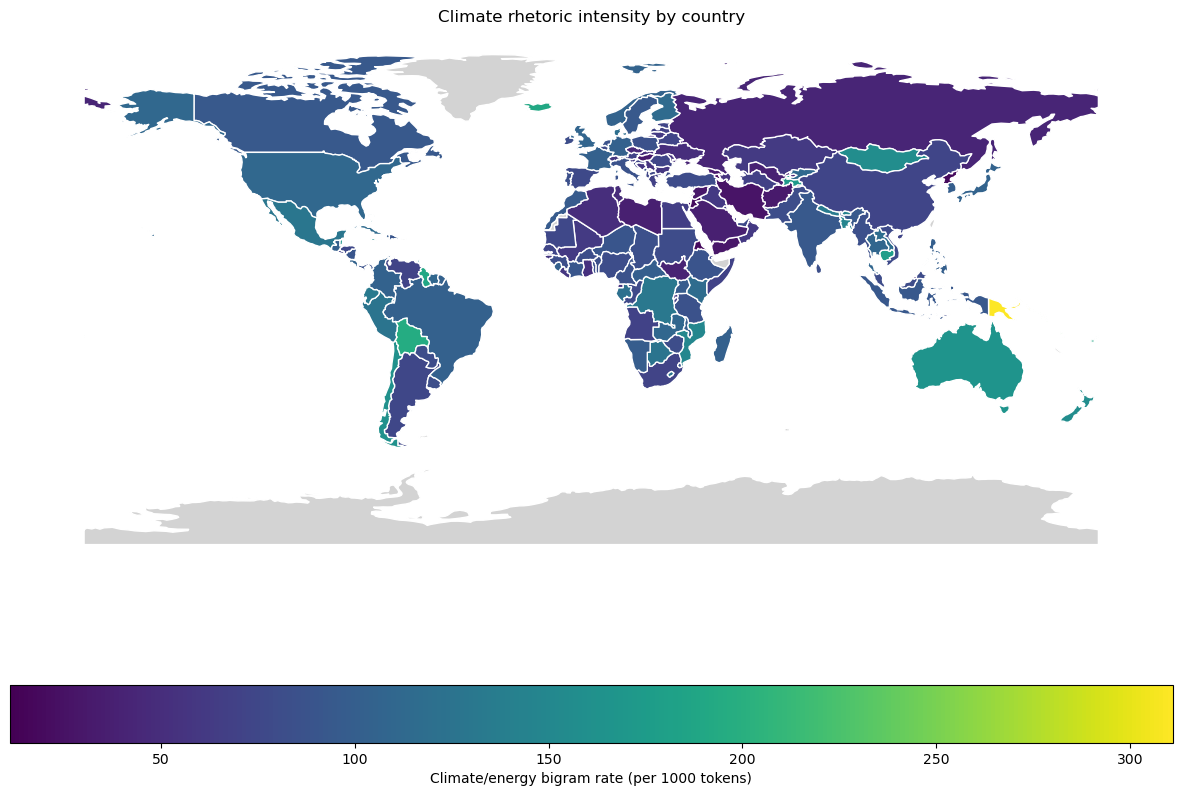

In [38]:
fig, ax = plt.subplots(figsize=(15, 10))
world_climate_final.plot(
    "bigram_rate_1000",
    ax=ax,
    legend=True,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={"label": "Climate/energy bigram rate (per 1000 tokens)", "orientation": "horizontal"}
)
ax.set_title("Climate rhetoric intensity by country")
ax.axis('off')
plt.show()

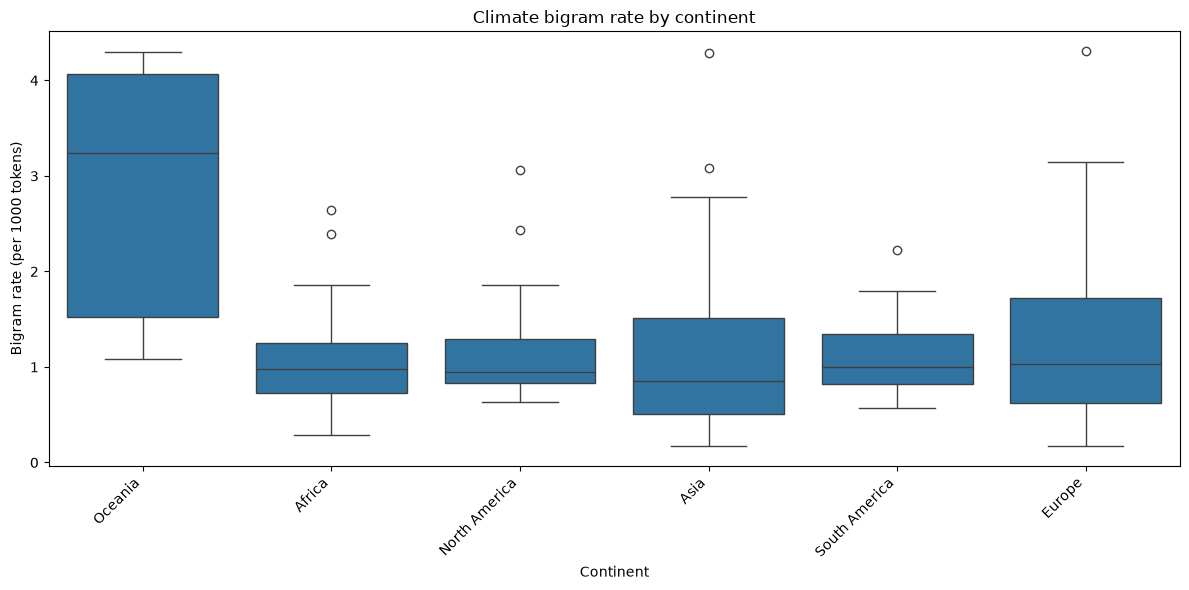

In [ ]:
import seaborn as sns

plot_data = world_climate_final[
    ~world_climate_final['CONTINENT'].isin(['Antarctica', 'Seven seas (open ocean)'])
]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=plot_data, x='CONTINENT', y='bigram_rate_1000', ax=ax)
ax.set_title('Climate bigram rate by continent')
ax.set_xlabel('Continent')
ax.set_ylabel('Bigram rate (per 1000 tokens)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()